In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['backend'] = 'module://ipykernel.pylab.backend_inline'

Train shape : (832, 28)
Test  shape : (208, 28)
Train class balance : {np.int64(0): np.int64(416), np.int64(1): np.int64(416)}
Test  class balance : {np.int64(0): np.int64(104), np.int64(1): np.int64(104)}

Features selected : [ 0  2  3  4  5  6  7  9 10 14 15 16 17 18 19 20 21 22 24 27]

  5-FOLD CV RESULTS ON TRAINING SET
  Logistic Regression (Baseline)       Acc: 1.0000 ± 0.0000   AUC: 1.0000
  SVM (RBF)                            Acc: 0.9940 ± 0.0000   AUC: 1.0000
  SVM (Linear)                         Acc: 1.0000 ± 0.0000   AUC: 1.0000
  Random Forest                        Acc: 1.0000 ± 0.0000   AUC: 1.0000
  Gradient Boosting                    Acc: 1.0000 ± 0.0000   AUC: 1.0000
  K-Nearest Neighbors                  Acc: 0.9628 ± 0.0188   AUC: 0.9936
  Naive Bayes                          Acc: 0.9952 ± 0.0070   AUC: 1.0000

[Tuning SVM...]
  Best SVM : {'C': 10, 'gamma': 0.01}  →  CV Acc: 1.0000
[Tuning Random Forest...]
  Best RF  : {'max_depth': 6, 'min_samples_split': 2, 'n

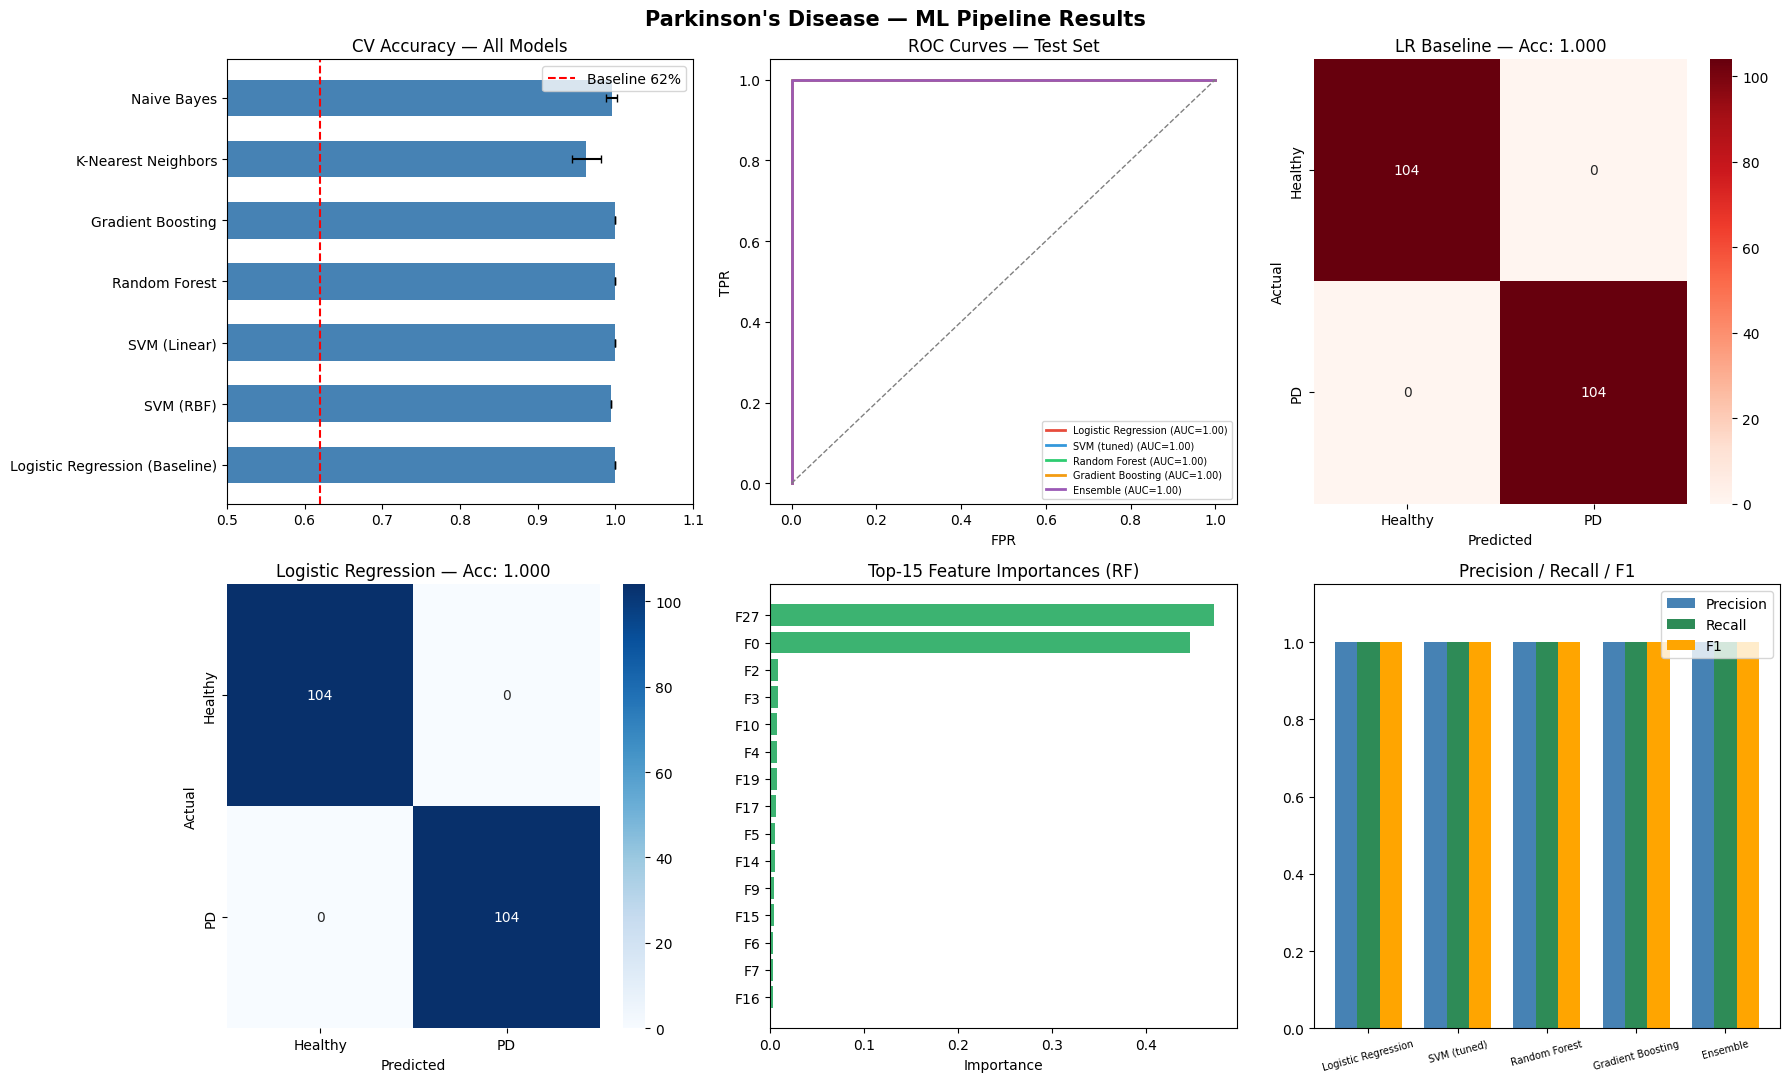

In [ ]:
# ============================================================
#  Parkinson's Disease — Binary Classification Pipeline
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               VotingClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve,
                              precision_score, recall_score, f1_score)
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# ── STEP 1: LOAD DATA ─────────────────────────────────────────────────────────

train = pd.read_csv('/content/parkinsons_train_scaled(1).csv')
test  = pd.read_csv('/content/parkinsons_test_scaled(1).csv')

X_train = train.drop('28', axis=1).values
y_train = train['28'].values
X_test  = test.drop('28', axis=1).values
y_test  = test['28'].values

print(f"Train shape : {X_train.shape}")
print(f"Test  shape : {X_test.shape}")
print(f"Train class balance : {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Test  class balance : {dict(zip(*np.unique(y_test,  return_counts=True)))}")

# ── STEP 2: FEATURE SELECTION ─────────────────────────────────────────────────
selector = SelectKBest(mutual_info_classif, k=20)
X_train_sel = selector.fit_transform(X_train, y_train)
X_test_sel  = selector.transform(X_test)
print(f"\nFeatures selected : {np.where(selector.get_support())[0]}")

# ── STEP 3: CROSS-VALIDATION COMPARISON ───────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression (Baseline)': LogisticRegression(max_iter=1000, random_state=42),
    'SVM (RBF)':                      SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42),
    'SVM (Linear)':                   SVC(kernel='linear', C=1, probability=True, random_state=42),
    'Random Forest':                  RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42),
    'Gradient Boosting':              GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=42),
    'K-Nearest Neighbors':            KNeighborsClassifier(n_neighbors=7),
    'Naive Bayes':                    GaussianNB(),
}

print("\n" + "="*60)
print("  5-FOLD CV RESULTS ON TRAINING SET")
print("="*60)

cv_results = {}
for name, model in models.items():
    acc = cross_val_score(model, X_train_sel, y_train, cv=cv, scoring='accuracy')
    auc = cross_val_score(model, X_train_sel, y_train, cv=cv, scoring='roc_auc')
    cv_results[name] = {'acc_mean': acc.mean(), 'acc_std': acc.std(), 'auc_mean': auc.mean()}
    print(f"  {name:<35}  Acc: {acc.mean():.4f} ± {acc.std():.4f}   AUC: {auc.mean():.4f}")

# ── STEP 4: HYPERPARAMETER TUNING ─────────────────────────────────────────────
print("\n[Tuning SVM...]")
svm_grid = GridSearchCV(
    SVC(kernel='rbf', probability=True, random_state=42),
    {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto', 0.01, 0.001]},
    cv=cv, scoring='accuracy', n_jobs=-1)
svm_grid.fit(X_train_sel, y_train)
print(f"  Best SVM : {svm_grid.best_params_}  →  CV Acc: {svm_grid.best_score_:.4f}")

print("[Tuning Random Forest...]")
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    {'n_estimators': [100, 300], 'max_depth': [6, 10, None], 'min_samples_split': [2, 5]},
    cv=cv, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train_sel, y_train)
print(f"  Best RF  : {rf_grid.best_params_}  →  CV Acc: {rf_grid.best_score_:.4f}")

# ── STEP 5: ENSEMBLE ──────────────────────────────────────────────────────────
best_svm = svm_grid.best_estimator_
best_rf  = rf_grid.best_estimator_
best_gb  = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=42)

ensemble = VotingClassifier(
    estimators=[('svm', best_svm), ('rf', best_rf), ('gb', best_gb)],
    voting='soft')

ens_acc = cross_val_score(ensemble, X_train_sel, y_train, cv=cv, scoring='accuracy')
print(f"\nEnsemble CV Acc: {ens_acc.mean():.4f} ± {ens_acc.std():.4f}")

# ── STEP 6: TRAIN ON FULL TRAINING SET & EVALUATE ON TEST ─────────────────────
best_svm.fit(X_train_sel, y_train)
best_rf.fit(X_train_sel, y_train)
best_gb.fit(X_train_sel, y_train)
ensemble.fit(X_train_sel, y_train)

lr_base = LogisticRegression(max_iter=1000, random_state=42)
lr_base.fit(X_train_sel, y_train)

print("\n" + "="*60)
print("  FINAL TEST SET RESULTS")
print("="*60)

test_results = {}
for label, fitted_model in [('Logistic Regression', lr_base),
                              ('SVM (tuned)',         best_svm),
                              ('Random Forest',       best_rf),
                              ('Gradient Boosting',   best_gb),
                              ('Ensemble',            ensemble)]:
    preds = fitted_model.predict(X_test_sel)
    proba = fitted_model.predict_proba(X_test_sel)[:, 1]
    acc   = accuracy_score(y_test, preds)
    auc   = roc_auc_score(y_test, proba)
    test_results[label] = {'preds': preds, 'proba': proba, 'acc': acc, 'auc': auc}
    print(f"  {label:<25}  Acc: {acc:.4f}   AUC: {auc:.4f}")

best_label = max(test_results, key=lambda k: test_results[k]['acc'])
best_preds = test_results[best_label]['preds']
best_proba = test_results[best_label]['proba']

print(f"\n★ Best model: {best_label}")
print(f"\n{classification_report(y_test, best_preds, target_names=['Healthy', 'PD'])}")

# ── STEP 7: SAVE MODEL  ───────────────────
joblib.dump(ensemble, 'parkinson_best_model.pkl')
print(f"Model saved → parkinson_best_model.pkl  (in {os.getcwd()})")

# ── STEP 8: VISUALISATIONS ────────────────────────────────────────────────────
# ── STEP 8: VISUALISATIONS  ──────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()
COLORS = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

# Plot 1 — CV Accuracy
ax = axes[0]
names = list(cv_results.keys())
accs  = [v['acc_mean'] for v in cv_results.values()]
stds  = [v['acc_std']  for v in cv_results.values()]
ax.barh(names, accs, xerr=stds, color='steelblue', height=0.6, capsize=3)
ax.axvline(0.62, color='red', ls='--', lw=1.5, label='Baseline 62%')
ax.set_xlim(0.5, 1.1)
ax.set_title('CV Accuracy — All Models')
ax.legend()

# Plot 2 — ROC Curves
ax = axes[1]
for i, (lbl, res) in enumerate(test_results.items()):
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    ax.plot(fpr, tpr, color=COLORS[i % len(COLORS)], lw=2,
            label=f"{lbl} (AUC={res['auc']:.2f})")
ax.plot([0,1],[0,1],'--', color='gray', lw=1)
ax.set_title('ROC Curves — Test Set')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.legend(fontsize=7)

# Plot 3 — Confusion Matrix Baseline
ax = axes[2]
cm_lr = confusion_matrix(y_test, test_results['Logistic Regression']['preds'])
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Reds', ax=ax,
            xticklabels=['Healthy','PD'], yticklabels=['Healthy','PD'])
ax.set_title(f"LR Baseline — Acc: {test_results['Logistic Regression']['acc']:.3f}")
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

# Plot 4 — Confusion Matrix Best Model
ax = axes[3]
cm_best = confusion_matrix(y_test, best_preds)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Healthy','PD'], yticklabels=['Healthy','PD'])
ax.set_title(f'{best_label} — Acc: {test_results[best_label]["acc"]:.3f}')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

# Plot 5 — Feature Importances
ax = axes[4]
importances = best_rf.feature_importances_
feat_labels = [f'F{i}' for i in np.where(selector.get_support())[0]]
top_idx = np.argsort(importances)[-15:]
ax.barh([feat_labels[i] for i in top_idx], importances[top_idx], color='mediumseagreen')
ax.set_title('Top-15 Feature Importances (RF)')
ax.set_xlabel('Importance')

# Plot 6 — Precision / Recall / F1
ax = axes[5]
xlabels = list(test_results.keys())
x = np.arange(len(xlabels))
w = 0.25
ax.bar(x - w, [precision_score(y_test, r['preds']) for r in test_results.values()], w, label='Precision', color='steelblue')
ax.bar(x,     [recall_score(y_test,    r['preds']) for r in test_results.values()], w, label='Recall',    color='seagreen')
ax.bar(x + w, [f1_score(y_test,        r['preds']) for r in test_results.values()], w, label='F1',        color='orange')
ax.set_xticks(x)
ax.set_xticklabels(xlabels, rotation=15, fontsize=7)
ax.set_ylim(0, 1.15)
ax.set_title('Precision / Recall / F1')
ax.legend()

plt.suptitle("Parkinson's Disease — ML Pipeline Results", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('parkinson_results.png', dpi=150, bbox_inches='tight')
plt.show()



In [ ]:
import matplotlib
print(matplotlib.get_backend())

module://ipykernel.pylab.backend_inline


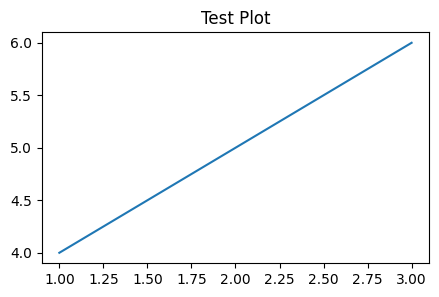

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,3))
plt.plot([1, 2, 3], [4, 5, 6])
plt.title("Test Plot")
plt.show()